In [ ]:
#pip install matplotlib

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

2026-05-10 15:37:31.783114: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-10 15:37:31.815304: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-10 15:37:32.475479: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/pb/anaconda3/envs/tf-gpu/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py

In [2]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [3]:
X_train_full.shape, X_train_full.dtype

((60000, 28, 28), dtype('uint8'))

In [4]:
X_test.shape

(10000, 28, 28)

In [5]:
X_train_full[1][0][0]

np.uint8(0)

In [6]:
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000] , y_train_full[5000:] 
X_test = X_test / 255

In [7]:
len(X_valid)

5000

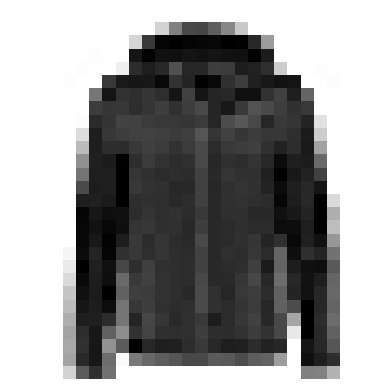

In [8]:
plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

In [9]:
y_train.shape, y_train.dtype

((55000,), dtype('uint8'))

In [10]:
y_train[0]

np.uint8(4)

In [11]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [12]:
class_names[y_train[0]]

'Coat'

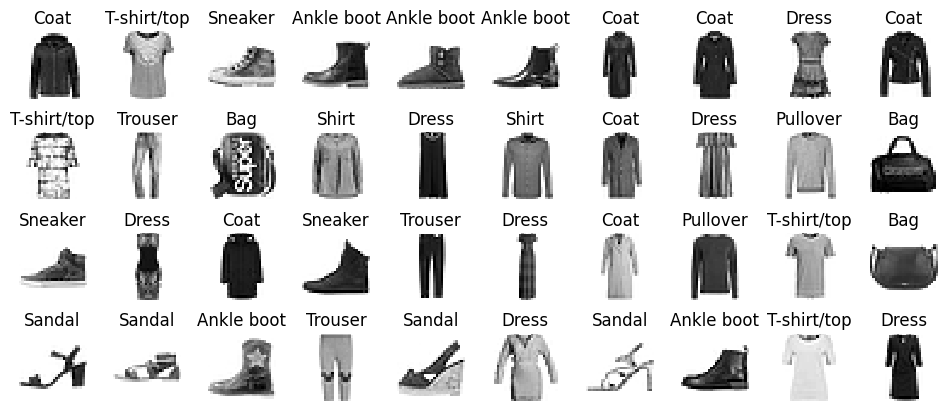

In [13]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis("off")
        plt.title(class_names[y_train[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

In [268]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28]))
model.add(keras.layers.Dense(200, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dense(10, activation="softmax"))

/home/pb/anaconda3/envs/tf-gpu/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [269]:
keras.backend.clear_session()
np.random.seed(99)
tf.random.set_seed(42)

In [270]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [271]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │       157,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,110 (695.74 KB)

 Trainable params: 178,110 (695.74 KB)

 Non-trainable params: 0 (0.00 B)

In [272]:
#pip install pydot

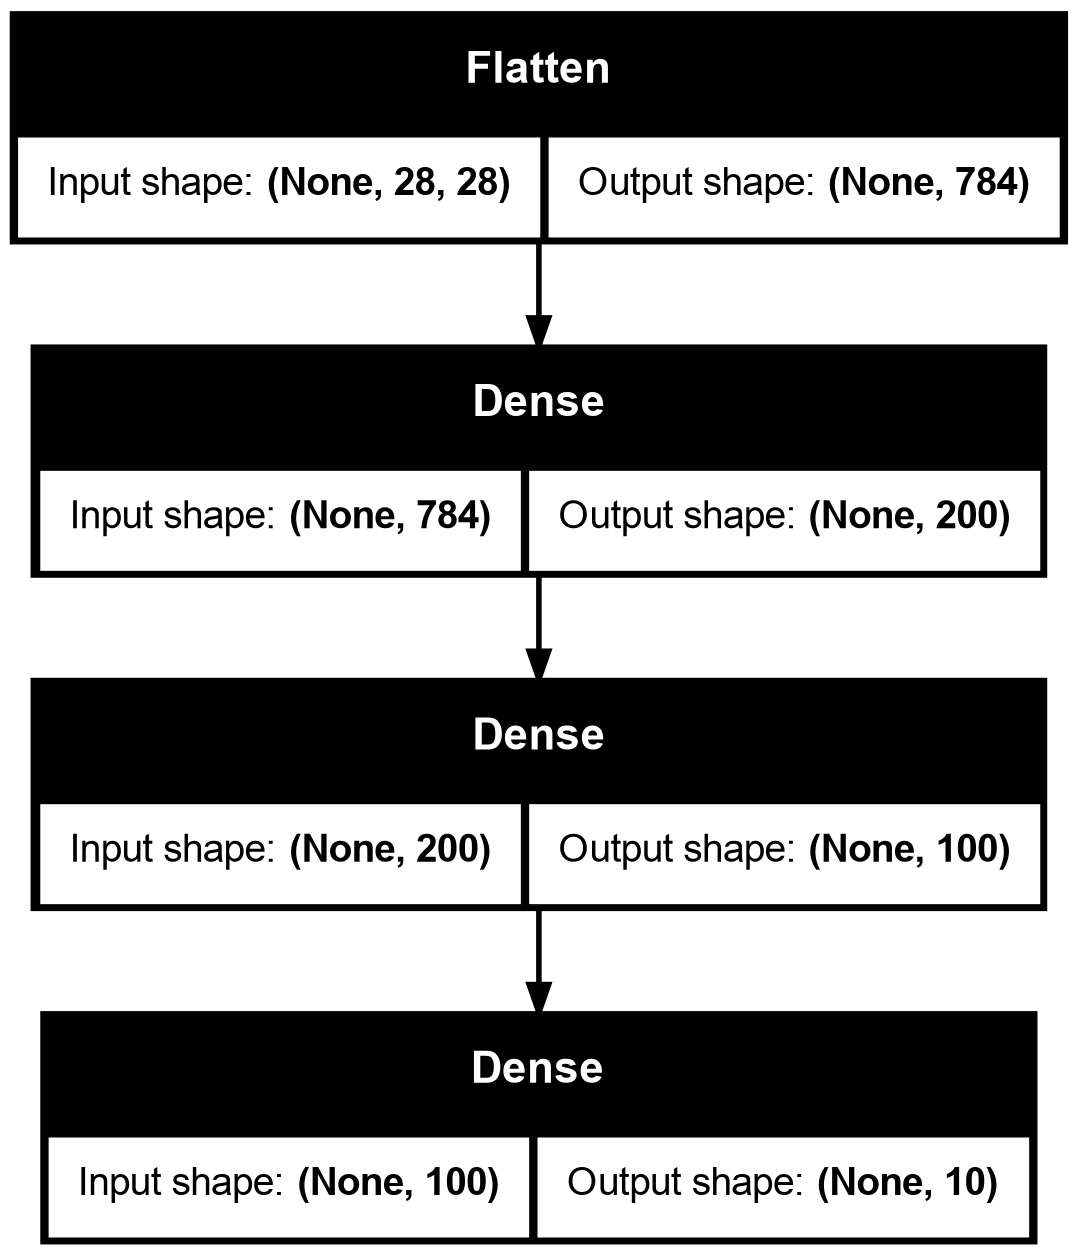

In [273]:
keras.utils.plot_model(model, "My_Fashion_Mnist_model.png", show_shapes=True)

In [274]:
hidden1 = model.layers[1]
hidden1.name

'dense'

In [275]:
weights, biases = hidden1.get_weights()

In [276]:
weights.shape

(784, 200)

In [277]:
biases.shape

(200,)

In [278]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              metrics=["accuracy"])

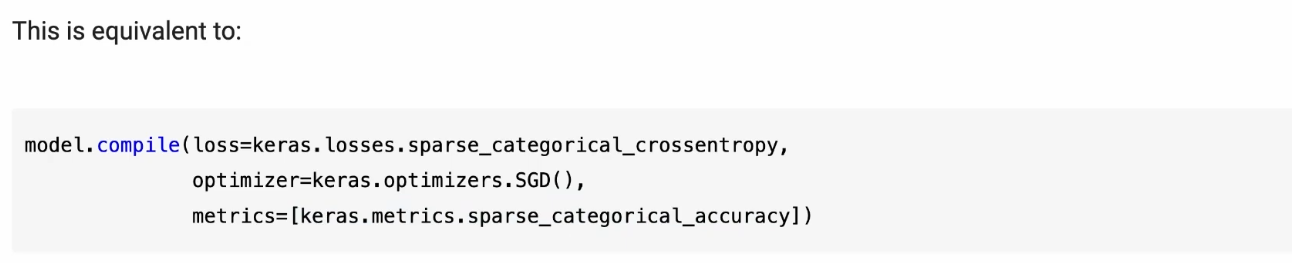

In [279]:
history = model.fit(X_train, y_train, epochs=50, batch_size=48,
                    validation_data=(X_valid, y_valid))

Epoch 1/50
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7773 - loss: 0.6906 - val_accuracy: 0.8348 - val_loss: 0.4710
Epoch 2/50
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 1s 890us/step - accuracy: 0.8465 - loss: 0.4479 - val_accuracy: 0.8566 - val_loss: 0.4115
Epoch 3/50
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 1s 813us/step - accuracy: 0.8607 - loss: 0.4050 - val_accuracy: 0.8648 - val_loss: 0.3828
Epoch 4/50
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 1s 851us/step - accuracy: 0.8684 - loss: 0.3795 - val_accuracy: 0.8710 - val_loss: 0.3659
Epoch 5/50
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - accuracy: 0.8740 - loss: 0.3611 - val_accuracy: 0.8730 - val_loss: 0.3533
Epoch 6/50
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step - accuracy: 0.8784 - loss: 0.3462 - val_accuracy: 0.8772 - val_loss: 0.3435
Epoch 7/50
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 1s 851us/step - accuracy: 0.8818 - loss: 0.3336 - val_accuracy: 0.8784 - val_loss: 0.3357
Epoch 8/50
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - accuracy: 0.8853 - l

Check for the point where validation loss starts increasing after constantly decreasing. After that point the model is overfitting
If the validation loss is much higher than training loss --> Overfit

In [280]:
history.params

{'verbose': 'auto', 'epochs': 50, 'steps': 1146}

In [281]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


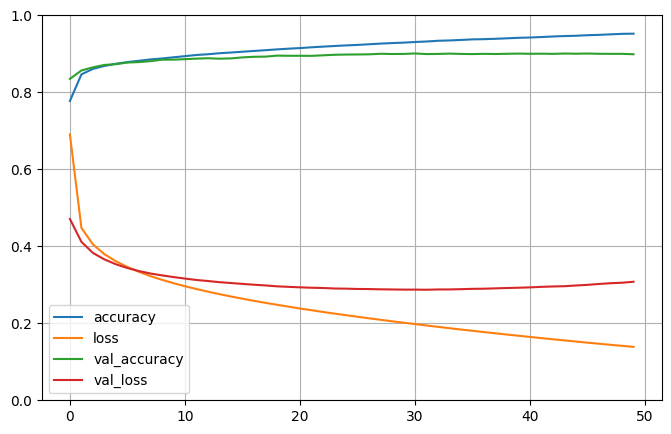

In [282]:
import pandas as pd

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()


In [283]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [284]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8889 - loss: 0.3429


[0.34288251399993896, 0.8888999819755554]

In [285]:
X_new = X_test[:3]

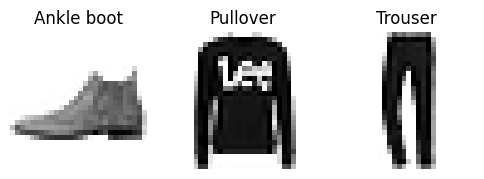

In [286]:
plt.figure(figsize=(6, 2))
for index, image in enumerate(X_new):
    plt.subplot(1, 3, index + 1)
    plt.imshow(image, cmap="binary", interpolation="nearest")
    plt.axis('off')
    plt.title(class_names[y_test[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

In [287]:
y_pred = np.argmax(model.predict(X_new), axis=-1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step


array([9, 2, 1])

In [288]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')